In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
print(torch.cuda.is_available())

True


In [10]:
#importing the data
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")
df.shape
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [4]:
#In a binary classification model, having balanced 0s and 1s (roughly similar numbers of both classes) is often
#important because otherwise the model can become biased toward the majority class.
df.target.value_counts(normalize=True, dropna=False)

,proportion
target,
0,0.726073
1,0.273927


In [11]:
#preprocessing
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")
categorical_variables = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'ca', 'thal']
numerics = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']
df = pd.get_dummies(df, columns = categorical_variables, dtype=np.int64)
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,67,160,286,108,1.5,2,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,67,120,229,129,2.6,2,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,37,130,250,187,3.5,3,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,41,130,204,172,1.4,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [12]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)

In [13]:
train_df.shape

(242, 30)

In [14]:
test_df.shape

(61, 30)

In [16]:
mean = train_df[numerics].mean()
sd = train_df[numerics].std()
mean
sd

,0
age,9.059861
trestbps,18.012789
chol,48.485377
thalach,23.132298
oldpeak,1.169729
slope,0.632783


In [17]:
train_df[numerics] = (train_df[numerics] - mean)/sd
test_df[numerics] = (test_df[numerics] - mean)/sd
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [18]:
#since numpy array is a accepted format we use numpy arrays

In [19]:
train = train_df.to_numpy()
test = test_df.to_numpy()
#seperating our features from output y
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

In [22]:
#number of input features
num_colums = train_X.shape[1]

class BinaryClassifier(nn.Module):
  def __init__(self, input_dim):
    super(BinaryClassifier, self).__init__()
    self.hidden = nn.Linear(input_dim, 16)
    self.relu = nn.ReLU()
    self.output = nn.Linear(16,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.hidden(x)
    x = self.relu(x)
    x = self.output(x)
    x = self.sigmoid(x)
    return x

model = BinaryClassifier(num_colums)

print(model)

BinaryClassifier(
  (hidden): Linear(in_features=29, out_features=16, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [38]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Extract train_y from the original 'train' numpy array before the target column was deleted
train_y = train[:, 6] # Assuming target is at index 6 in the 'train' array

X = torch.tensor(train_X, dtype=torch.float32)
y = torch.tensor(train_y, dtype=torch.float32).view(-1,1)

# Store training loss
loss_values = []

for epoch in range(300):
    optimizer.zero_grad()

    outputs = model(X)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()

    loss_values.append(loss.item()) # Store loss

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

print("Training complete")

Epoch 1, Loss: 0.0708
Epoch 2, Loss: 0.0708
Epoch 3, Loss: 0.0704
Epoch 4, Loss: 0.0702
Epoch 5, Loss: 0.0700
Epoch 6, Loss: 0.0697
Epoch 7, Loss: 0.0695
Epoch 8, Loss: 0.0692
Epoch 9, Loss: 0.0690
Epoch 10, Loss: 0.0688
Epoch 11, Loss: 0.0686
Epoch 12, Loss: 0.0683
Epoch 13, Loss: 0.0681
Epoch 14, Loss: 0.0679
Epoch 15, Loss: 0.0676
Epoch 16, Loss: 0.0674
Epoch 17, Loss: 0.0672
Epoch 18, Loss: 0.0669
Epoch 19, Loss: 0.0667
Epoch 20, Loss: 0.0665
Epoch 21, Loss: 0.0663
Epoch 22, Loss: 0.0660
Epoch 23, Loss: 0.0658
Epoch 24, Loss: 0.0656
Epoch 25, Loss: 0.0653
Epoch 26, Loss: 0.0651
Epoch 27, Loss: 0.0649
Epoch 28, Loss: 0.0647
Epoch 29, Loss: 0.0644
Epoch 30, Loss: 0.0642
Epoch 31, Loss: 0.0640
Epoch 32, Loss: 0.0638
Epoch 33, Loss: 0.0636
Epoch 34, Loss: 0.0633
Epoch 35, Loss: 0.0631
Epoch 36, Loss: 0.0629
Epoch 37, Loss: 0.0627
Epoch 38, Loss: 0.0625
Epoch 39, Loss: 0.0623
Epoch 40, Loss: 0.0620
Epoch 41, Loss: 0.0618
Epoch 42, Loss: 0.0616
Epoch 43, Loss: 0.0614
Epoch 44, Loss: 0.06

In [39]:
history_dict = {'loss': loss_values}
history_dict.keys()

dict_keys(['loss'])

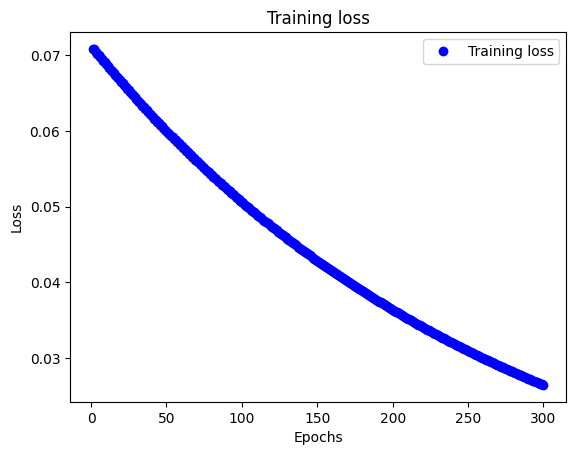

In [40]:
loss_values = history_dict["loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.title("Training loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()